# 1: Cài đặt thư viện, chuẩn bị môi trường

In [1]:
# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Cài đặt thư viện
!pip install faiss-cpu pandas numpy spacy matplotlib seaborn scikit-learn tqdm

# 3. Tải model Spacy
!python -m spacy download en_core_web_sm

# 4. Import và kiểm tra
import pandas as pd
import numpy as np
import spacy
import re
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- Cài đặt thành công! ---")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 87.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 129.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
--- Cài đặt thành công! ---


# 2: Import lại thư viện sau khi cài đặt thư viện(cần thiết để nhận thư viện)

In [1]:
# CHẠY CELL NÀY ĐẦU TIÊN SAU KHI RESTART
import pandas as pd
import numpy as np
import spacy
import re
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from spacy.pipeline import EntityRuler
from google.colab import drive

# Kiểm tra mount drive (nếu chưa mount thì nó sẽ yêu cầu xác nhận)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print("Đã nạp xong thư viện.")

Đã nạp xong thư viện.


# 3: Tiền xử lý dữ liệu

In [2]:
file_path = '/content/drive/MyDrive/wikihowAll.csv'

def preprocess_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

try:
    df = pd.read_csv(file_path)

    # Lọc các dòng có headline liên quan đến nguyên liệu/dụng cụ
    keywords = ['material', 'thing', 'need', 'tool', 'equipment', 'ingredient']
    mask = df['headline'].str.contains('|'.join(keywords), case=False, na=False)
    df_filtered = df[mask].copy()

    # Làm sạch text
    df_filtered['clean_text'] = df_filtered['text'].apply(preprocess_text)

    print(f"Số lượng bản ghi nguyên liệu tìm thấy: {len(df_filtered)}")
    display(df_filtered[['title', 'headline']].head())
except Exception as e:
    print(f"Lỗi đọc file: {e}")

Số lượng bản ghi nguyên liệu tìm thấy: 45920


,title,headline
0,How to Be an Organized Artist1,"\nKeep related supplies in the same area.,\nMa..."
1,How to Create a Neopoprealist Art Work,\nCreate a sketch in the NeoPopRealist manner ...
4,How to Be an Organized Artist2,"\nKeep your reference materials, sketches, art..."
5,How to Be an Organized Artist3,\nKeep all of your past work organized and acc...
8,How to Be Good at Improvisation,"\nMake sure you know what is expected of you.,..."


# 4: Train model với NER

In [3]:
import time
from tqdm import tqdm

# Tải mô hình, disable thành phần không cần
nlp = spacy.load("en_core_web_sm", disable=["parser", "tagger", "lemmatizer"])

# Thêm entity_ruler MATERIAL
if "entity_ruler" not in nlp.pipe_names:
    ruler = nlp.add_pipe("entity_ruler", before="ner")
else:
    ruler = nlp.get_pipe("entity_ruler")

material_patterns = [
    "plastic", "bottle", "paper", "cardboard", "glass", "metal", "can",
    "fabric", "wood", "glue", "tape"
]
patterns = [{"label": "MATERIAL", "pattern": [{"LOWER": m}]} for m in material_patterns]
ruler.add_patterns(patterns)


def extract_materials(text):
    doc = nlp(text)
    materials = [ent.text for ent in doc.ents if ent.label_ == "MATERIAL"]
    if not materials:
        lower_patterns = set(material_patterns)
        materials = [
            token.lemma_.lower()
            for token in doc
            if token.pos_ == "NOUN"
               and len(token.text) > 2
               and token.lemma_.lower() in lower_patterns
        ]
    return " ".join(set(materials))


print("Đang chạy NER...")
start_time = time.time()

texts = df_filtered["clean_text"].tolist()
extracted_materials = []

# Tạo iterator với tqdm cho tiến trình
for doc in tqdm(
    nlp.pipe(texts, batch_size=50),
    total=len(texts),
    desc="Processing texts",
    unit="doc",
):
    materials = [ent.text for ent in doc.ents if ent.label_ == "MATERIAL"]
    if not materials:
        lower_patterns = set(material_patterns)
        materials = [
            token.lemma_.lower()
            for token in doc
            if token.pos_ == "NOUN"
               and len(token.text) > 2
               and token.lemma_.lower() in lower_patterns
        ]
    extracted_materials.append(" ".join(set(materials)))

df_filtered["extracted_materials"] = extracted_materials
df_filtered = df_filtered[df_filtered["extracted_materials"] != ""].reset_index(drop=True)

elapsed_time = time.time() - start_time
print(f"Hoàn thành trích xuất NER. Thời gian xử lý: {elapsed_time:.2f} giây.")


Đang chạy NER...


Processing texts: 100%|██████████| 45920/45920 [35:47<00:00, 21.38doc/s]

Hoàn thành trích xuất NER. Thời gian xử lý: 2147.49 giây.


# 5: Khởi tạo FAISS

In [4]:
# 1. Vectorize
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df_filtered['extracted_materials']).astype('float32')
data_vectors = tfidf_matrix.toarray()
faiss.normalize_L2(data_vectors)

# 2. Xây dựng Index IVFFlat
dimension = data_vectors.shape[1]
nlist = int(np.sqrt(len(df_filtered))) if len(df_filtered) > 100 else 2
quantizer = faiss.IndexFlatIP(dimension)
index_ivf = faiss.IndexIVFFlat(quantizer, dimension, nlist, faiss.METRIC_INNER_PRODUCT)

# Thử đẩy lên GPU, nếu không có thì dùng CPU
try:
    res = faiss.StandardGpuResources()
    gpu_index = faiss.index_cpu_to_gpu(res, 0, index_ivf)
    print("Sử dụng FAISS GPU.")
except:
    gpu_index = index_ivf
    print("Sử dụng FAISS CPU.")

gpu_index.train(data_vectors)
gpu_index.add(data_vectors)

Sử dụng FAISS CPU.


# 6: Kiểm thử

In [5]:
def suggest_recycling(input_list, top_k=5):
    query_text = " ".join(input_list)
    query_clean = extract_materials(preprocess_text(query_text))

    query_vec = vectorizer.transform([query_clean]).toarray().astype('float32')
    faiss.normalize_L2(query_vec)

    # Tìm kiếm (Lấy dư để rerank)
    distances, indices = gpu_index.search(query_vec, top_k * 2)

    results = df_filtered.iloc[indices[0]].copy()
    results['raw_score'] = distances[0]

    # Boosting dựa trên Title
    boost_words = ['recycle', 'reuse', 'upcycle', 'diy', 'craft', 'homemade', 'make']
    def apply_boost(row):
        score = row['raw_score']
        # Nếu title chứa từ khóa tái chế, tăng 20% điểm số
        if any(word in str(row['title']).lower() for word in boost_words):
            return score * 1.2
        return score

    results['final_score'] = results.apply(apply_boost, axis=1)
    return results.sort_values('final_score', ascending=False).head(top_k)

# TEST THỰC TẾ
my_materials = ["plastic bottle", "scissors", "string"]
recommendations = suggest_recycling(my_materials)
display(recommendations[['title', 'headline', 'final_score']])

,title,headline,final_score
2905,How to Pack Your Gym Bag for School (Girls),"\nGet a gym bag that's right for you.,\nKnow t...",1.0
2772,How to Select a Lunchbox,\nGet a lunchbox that is larger than you think...,1.0
2629,How to Deal with Your Exams when You Are Autis...,"\nKnow where your exam is.,\nGather all necess...",1.0
2215,How to Pack an Overnight Bag for a Stay at You...,"\nChoose a big enough bag.,\nMake sure to keep...",1.0
2112,How to Pierce Your Own Penis3,"\nGet out your needle.,\nApply ointment.,\nLin...",1.0


# 7: Trực quan hoá kết quả kiểm thử

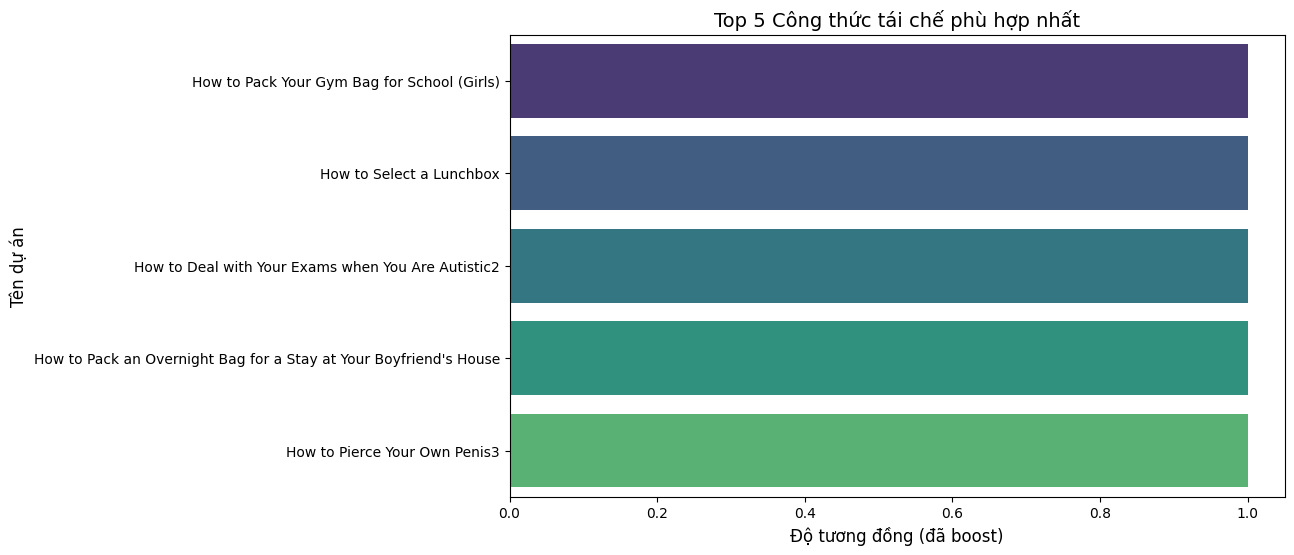

In [6]:
def plot_results(res_df):
    plt.figure(figsize=(10, 6))
    sns.set_palette("viridis")

    # Vẽ cột điểm số cuối cùng
    sns.barplot(data=res_df, x='final_score', y='title', hue='title', legend=False)

    plt.title('Top 5 Công thức tái chế phù hợp nhất', fontsize=14)
    plt.xlabel('Độ tương đồng (đã boost)', fontsize=12)
    plt.ylabel('Tên dự án', fontsize=12)
    plt.show()

plot_results(recommendations)